### Tensorflow and keras 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#pip install tensorflow

In [3]:
import tensorflow as tf
from tensorflow import keras

2025-11-24 11:23:06.992006: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-11-24 11:23:07.294633: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-11-24 11:23:28.797422: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-11-24 11:23:42.014447: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [4]:
from tensorflow.keras.preprocessing.image import load_img

In [5]:
path = './clothing-dataset-small/train/hat'
name = '00d94e21-5891-492e-be0e-792e7338c077.jpg'
fullname = f'{path}/{name}'


In [6]:
img = load_img(fullname, target_size=(299, 299))

In [7]:
X = np.array(img)
X.shape

(299, 299, 3)

In [8]:
X

array([[[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [113,   9,   6],
        [112,   8,   5],
        [110,   8,   4]],

       [[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [118,  10,   8],
        [115,  10,   7],
        [113,   9,   6]],

       [[161,  15,  15],
        [161,  15,  15],
        [161,  15,  15],
        ...,
        [126,  12,  12],
        [124,  12,  11],
        [121,  11,  10]],

       ...,

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [124,  10,  10],
        [126,  12,  12],
        [128,  14,  14]],

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [125,  11,  11],
        [126,  12,  12],
        [128,  14,  14]],

       [[101,   5,   7],
        [101,   5,   7],
        [101,   5,   7],
        ...,
        [125,  11,  11],
        [126,  12,  12],
        [127,  13,  13]]

### Pre-trained convolutional neural networks

https://www.image-net.org/

https://keras.io/api/applications/

In [9]:
from tensorflow.keras.applications.xception import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.applications.xception import decode_predictions

In [10]:
model = Xception(weights='imagenet', input_shape=(299, 299, 3))

2025-11-24 11:23:50.580766: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [11]:
X = np.array([X])

In [12]:
X = preprocess_input(X)

In [13]:
X[0]

array([[[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.11372548, -0.92941177, -0.9529412 ],
        [-0.12156862, -0.9372549 , -0.9607843 ],
        [-0.1372549 , -0.9372549 , -0.96862745]],

       [[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.0745098 , -0.92156863, -0.9372549 ],
        [-0.09803921, -0.92156863, -0.94509804],
        [-0.11372548, -0.92941177, -0.9529412 ]],

       [[ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        [ 0.26274514, -0.88235295, -0.88235295],
        ...,
        [-0.01176471, -0.90588236, -0.90588236],
        [-0.02745098, -0.90588236, -0.9137255 ],
        [-0.05098039, -0.9137255 , -0.92156863]],

       ...,

       [[-0.20784312, -0.9607843 , -0.94509804],
        [-0

In [14]:
pred = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [15]:
pred.shape

(1, 1000)

In [16]:
decode_predictions(pred)

[[('n03424325', 'gasmask', np.float32(0.1535756)),
  ('n02769748', 'backpack', np.float32(0.089838855)),
  ('n03709823', 'mailbag', np.float32(0.064012595)),
  ('n03595614', 'jersey', np.float32(0.04093369)),
  ('n02834397', 'bib', np.float32(0.024432804))]]

### Transfer learning

In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [18]:
train_gen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_ds = train_gen.flow_from_directory('./clothing-dataset-small/train'
                                         , target_size=(150, 150), 
                                         class_mode='sparse', 
                                         batch_size=32)

Found 3068 images belonging to 10 classes.


In [19]:
train_ds.class_indices

{'dress': 0,
 'hat': 1,
 'longsleeve': 2,
 'outwear': 3,
 'pants': 4,
 'shirt': 5,
 'shoes': 6,
 'shorts': 7,
 'skirt': 8,
 't-shirt': 9}

In [20]:
X,y = next(train_ds)

In [21]:
val_gen = ImageDataGenerator(preprocessing_function=preprocess_input)
val_ds = val_gen.flow_from_directory('./clothing-dataset-small/validation'
                                       , target_size=(150, 150), 
                                       class_mode='sparse',
                                       shuffle=False, 
                                       batch_size=32)

Found 341 images belonging to 10 classes.


In [22]:
base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
)
base_model.trainable = False

In [23]:
inputs = keras.Input(shape=(150, 150, 3))

base = base_model(inputs, training=False)

vectors = keras.layers.GlobalAveragePooling2D()(base)

outputs = keras.layers.Dense(10)(vectors)

model = keras.Model(inputs, outputs)

In [24]:
preds = model.predict(X)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [25]:
preds.shape

(32, 10)

In [26]:
preds[0]

array([-0.40592372,  1.1630301 ,  0.56713927,  1.4097432 , -0.14368266,
        0.15888828, -0.8223377 ,  1.0764171 , -0.9915751 ,  0.0965808 ],
      dtype=float32)

In [27]:
learning_rate=0.01
optimizer = keras.optimizers.Adam(learning_rate=learning_rate)

loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)

In [28]:
model.compile(optimizer=optimizer, loss=loss, metrics=['accuracy']) 

In [29]:
history = model.fit(train_ds, epochs=5, validation_data=val_ds)

Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.6838 - loss: 1.1541 - val_accuracy: 0.7801 - val_loss: 0.8353
Epoch 2/5
33/96 ━━━━━━━━━━━━━━━━━━━━ 1:15 1s/step - accuracy: 0.8480 - loss: 0.4630

KeyboardInterrupt: 

In [ ]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

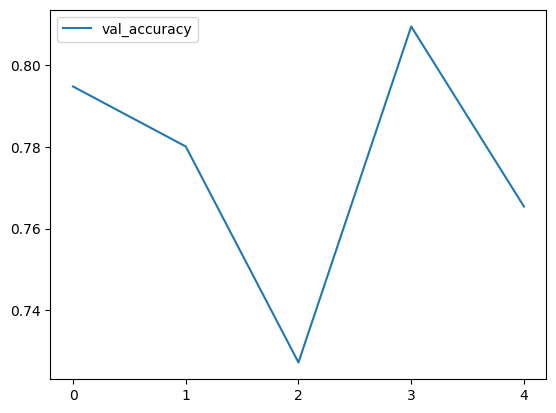

In [ ]:
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xticks(np.arange(5))
plt.legend()

### Adjusting learning rate

In [32]:
def make_model(learning_rate):
    base_model =Xception(
    weights='imagenet',
    include_top=False,
    input_shape=(150, 150, 3)
        )
    base_model.trainable = False
    #######################################################################
    inputs = keras.Input(shape=(150, 150, 3))
    base = base_model(inputs, training=False)
    vectors = keras.layers.GlobalAveragePooling2D()(base)
    outputs = keras.layers.Dense(10)(vectors)
    model = keras.Model(inputs, outputs)
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate)
    loss = keras.losses.SparseCategoricalCrossentropy(from_logits=True)
    #######################################################################
    model.compile(optimizer=optimizer,
                   loss=loss,
                   metrics=['accuracy']) 
    return model

In [33]:
scores = {}
for lr in [0.01,0.1, 0.001, 0.0001]:
    print(f'Training model with learning rate: {lr}')
    model = make_model(lr)
    history = model.fit(train_ds, epochs=5, validation_data=val_ds)
    scores[lr] = history.history

    print()
    print()

Training model with learning rate: 0.01
Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6822 - loss: 1.1991 - val_accuracy: 0.7302 - val_loss: 1.1777
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 124s 1s/step - accuracy: 0.8207 - loss: 0.5517 - val_accuracy: 0.8152 - val_loss: 0.7970
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.8882 - loss: 0.3278 - val_accuracy: 0.8035 - val_loss: 0.8947
Epoch 4/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.9153 - loss: 0.2594 - val_accuracy: 0.8006 - val_loss: 0.9008
Epoch 5/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9390 - loss: 0.1786 - val_accuracy: 0.8006 - val_loss: 0.9427


Training model with learning rate: 0.1
Epoch 1/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 128s 1s/step - accuracy: 0.6297 - loss: 11.3153 - val_accuracy: 0.7126 - val_loss: 7.5690
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 0.7813 - loss: 4.5526 - val_accuracy: 0.7126 - val_loss: 9.3198
Epoch 3/5
96/96 ━━━━━━━━━━━━━━━━━━━━

In [38]:
del scores[0.0001]
del scores [0.1]

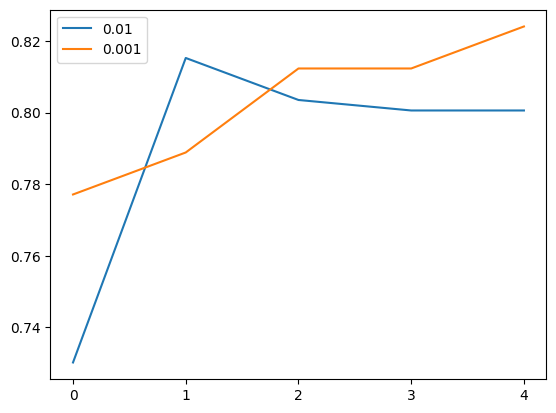

In [39]:
for lr, hist in scores.items():
    plt.plot(hist['val_accuracy'], label=lr)
plt.xticks(np.arange(5))
plt.legend()

In [ ]:
learning_rate = 0.001